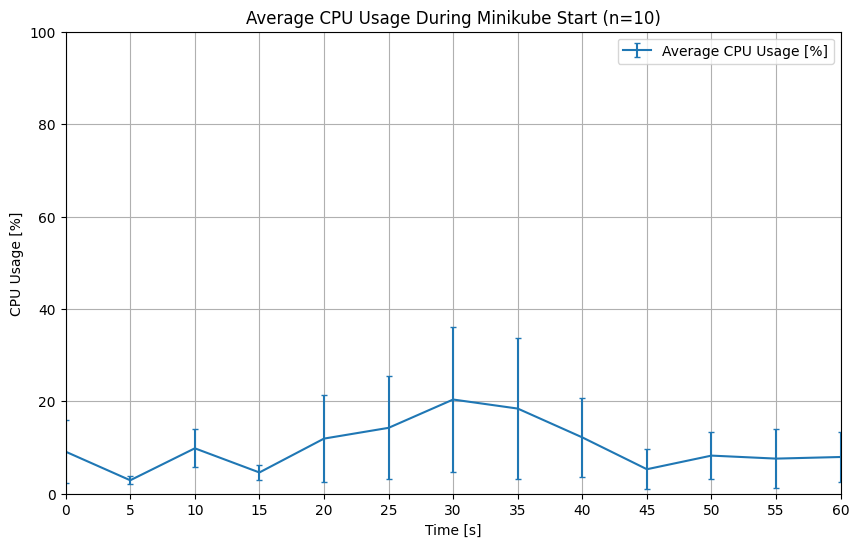

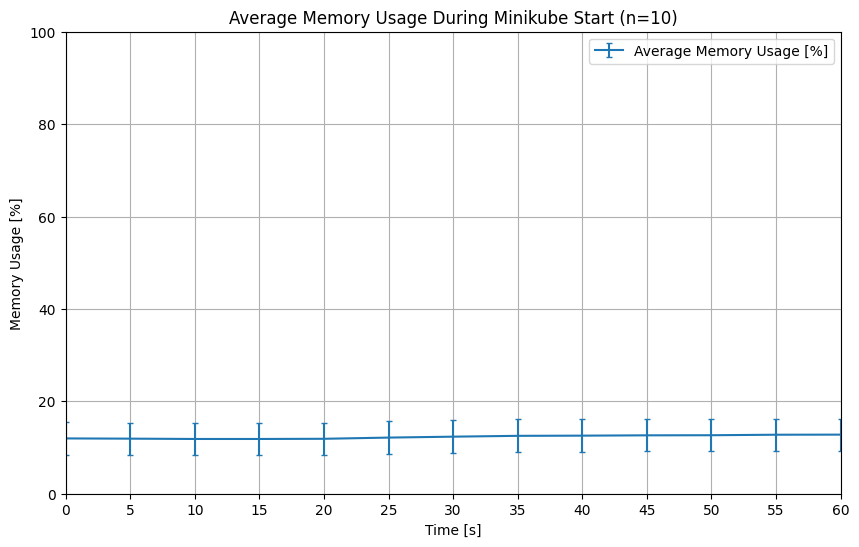

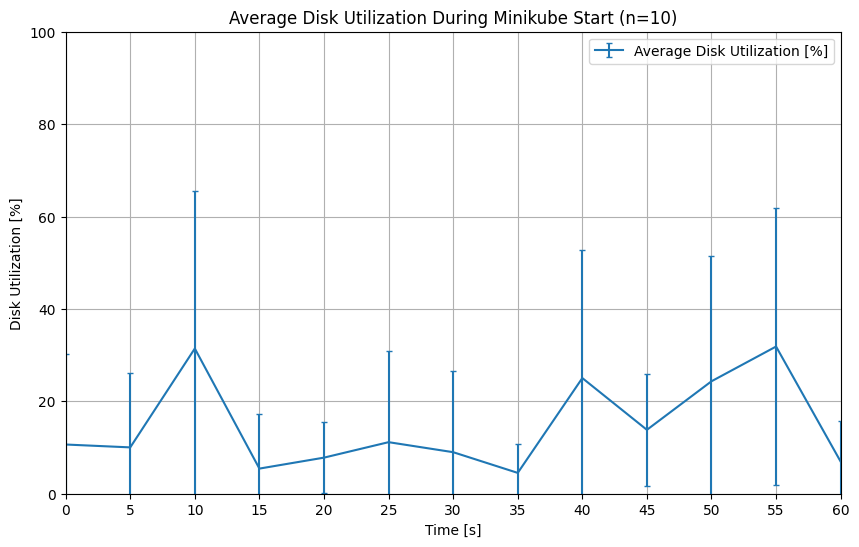

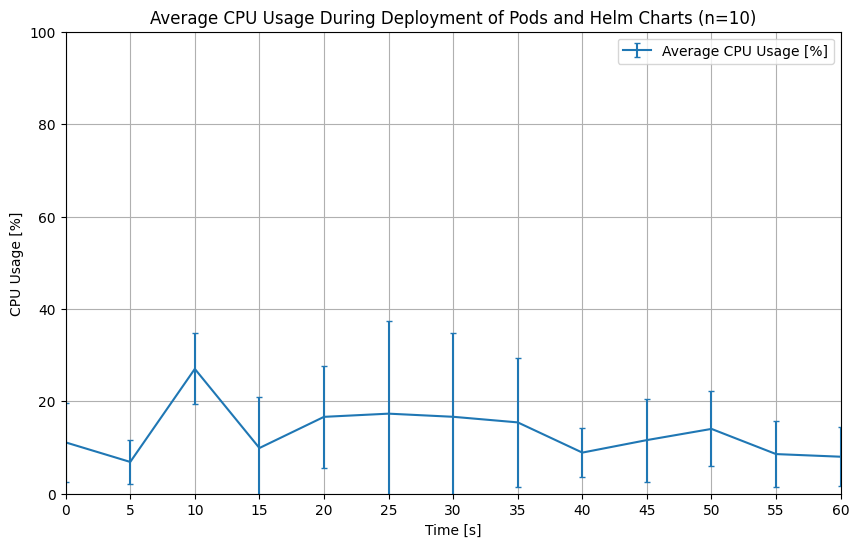

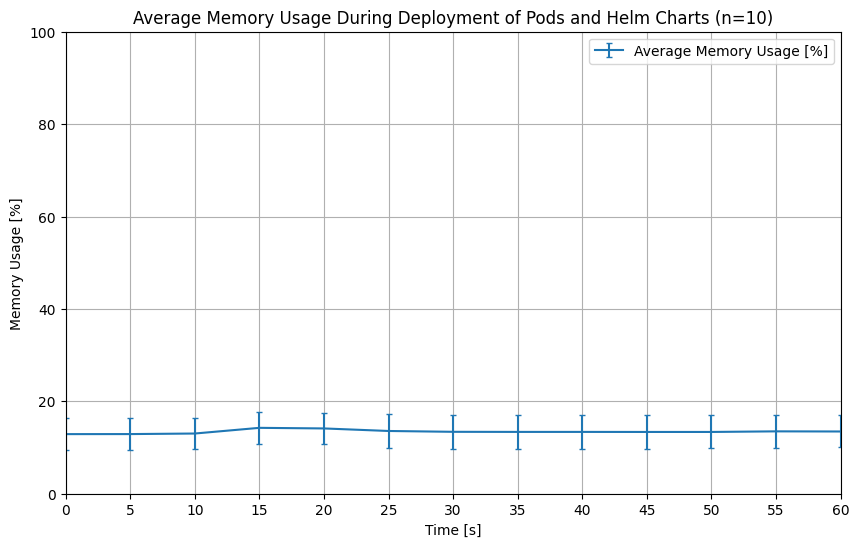

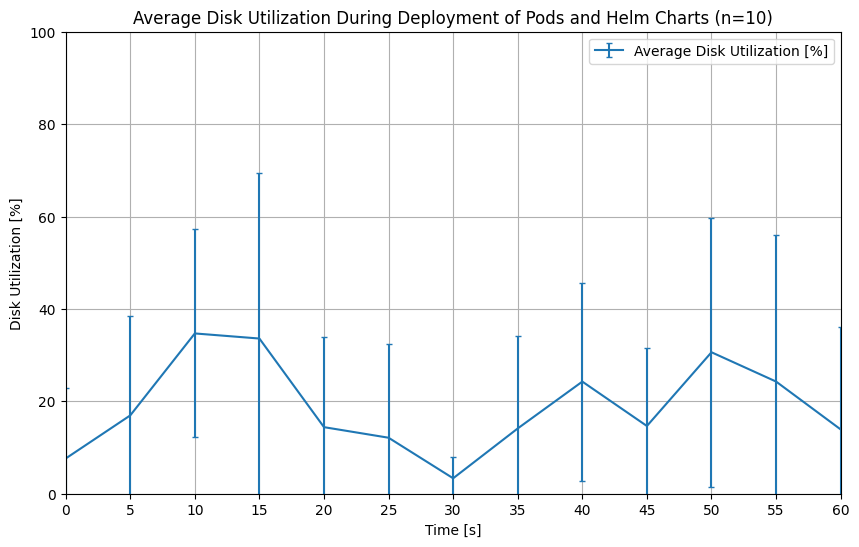

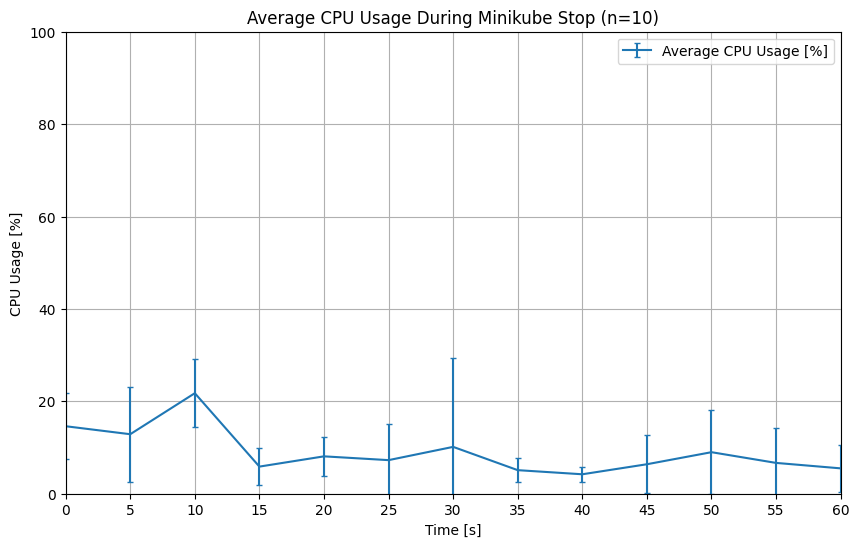

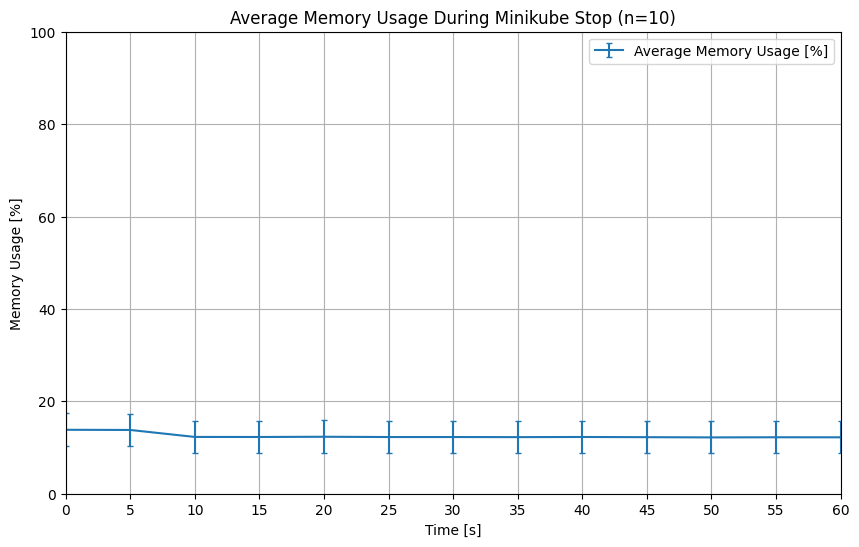

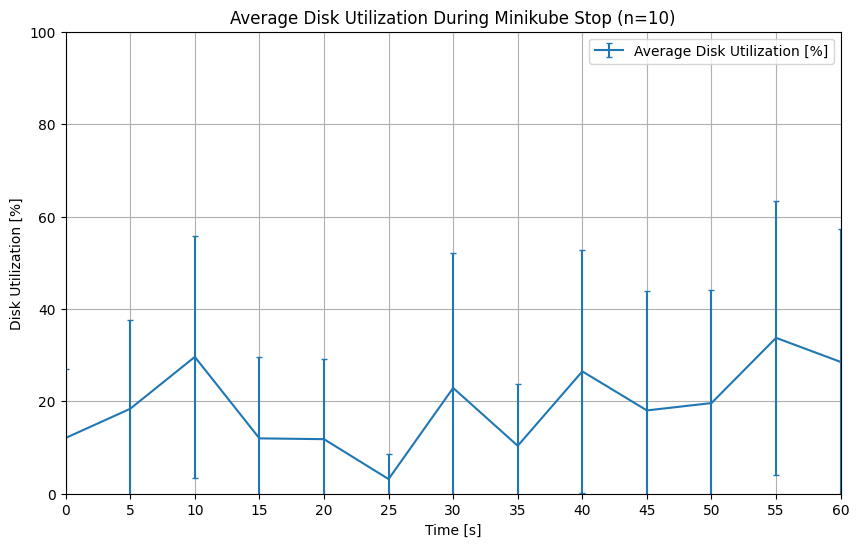

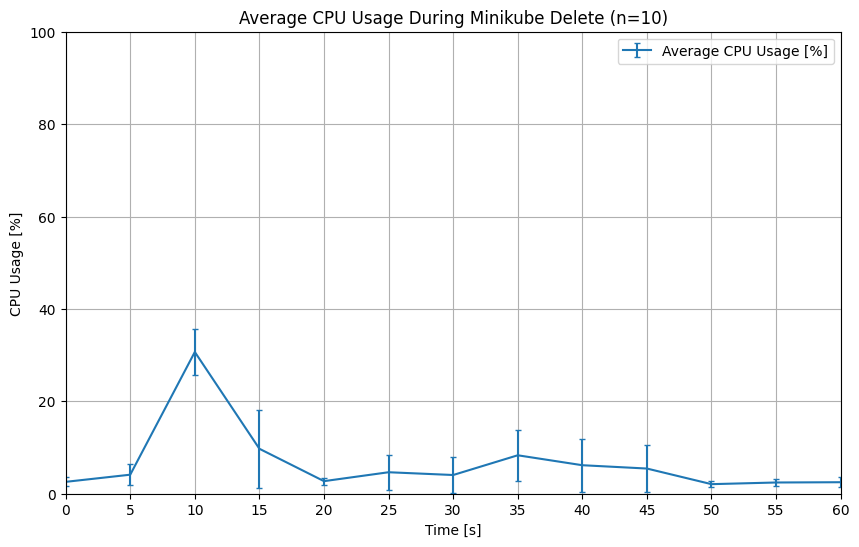

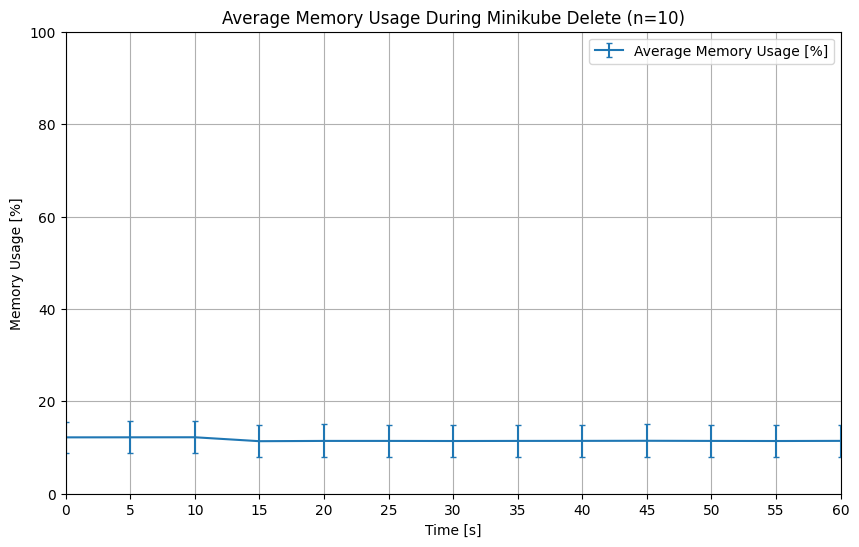

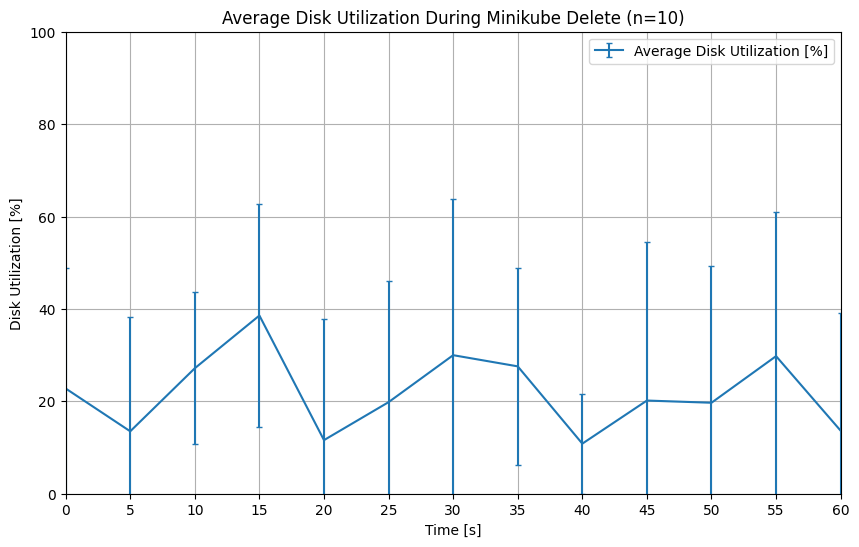

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Number of CSV files to process
NUM_FILES = 10

# Dictionary to store DataFrames for each phase
phases_data = {
    'start': [],
    'deployment': [],
    'end': [],
    'delete': []
}

# Read all CSV files
for i in range(1, NUM_FILES + 1):
    phases_data['start'].append(pd.read_csv(f"k3s-cpu_mem/start_{i}.csv"))
    phases_data['deployment'].append(pd.read_csv(f"k3s-cpu_mem/deployment_{i}.csv"))
    phases_data['end'].append(pd.read_csv(f"k3s-cpu_mem/end_{i}.csv"))
    phases_data['delete'].append(pd.read_csv(f"k3s-cpu_mem/delete_{i}.csv"))

# Calculate averages and standard deviations for each phase
avg_metrics = {}
std_metrics = {}
for phase, dfs in phases_data.items():
    # Initialize DataFrames
    avg_metrics[phase] = pd.DataFrame()
    std_metrics[phase] = pd.DataFrame()
    
    # Find minimum length across all files for this phase
    min_length = min(len(df) for df in dfs)
    
    # Trim all dataframes to minimum length
    dfs_trimmed = [df.iloc[:min_length] for df in dfs]
    
    # Use timestamp from first file
    avg_metrics[phase]['timestamp'] = dfs_trimmed[0]['timestamp'].str.replace('s', '').astype(float)
    
    # Calculate averages and std for each metric
    metrics = ['cpu_usage_percent', 'mem_usage_percent', 'disk_usage_percent']
    for metric in metrics:
        values = np.array([df[metric].values[:min_length] for df in dfs])
        avg_metrics[phase][metric] = np.mean(values, axis=0)
        std_metrics[phase][metric] = np.std(values, axis=0)
    
    # print('Metric:',metric)
    # print('Phase', phase)
    # print(std_metrics[phase][metric])

# Plot averaged results with error bars
phase_names = {
    'start': "Minikube Start",
    'deployment': "Deployment of Pods and Helm Charts",
    'end': "Minikube Stop",
    'delete': "Minikube Delete"
}

for phase, data in avg_metrics.items():
    # CPU Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['cpu_usage_percent'],
                yerr=std_metrics[phase]['cpu_usage_percent'],
                label='Average CPU Usage [%]',
                capsize=2)
    plt.title(f"Average CPU Usage During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("CPU Usage [%]")
    plt.grid()
    plt.legend()
    plt.show()

    # Memory Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['mem_usage_percent'],
                yerr=std_metrics[phase]['mem_usage_percent'],
                label='Average Memory Usage [%]',
                capsize=2)
    plt.title(f"Average Memory Usage During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("Memory Usage [%]")
    plt.grid()
    plt.legend()
    plt.show()

    # Disk Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['disk_usage_percent'],
                yerr=std_metrics[phase]['disk_usage_percent'],
                label='Average Disk Utilization [%]',
                capsize=2)
    plt.title(f"Average Disk Utilization During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("Disk Utilization [%]")
    plt.grid()
    plt.legend()
    plt.show()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

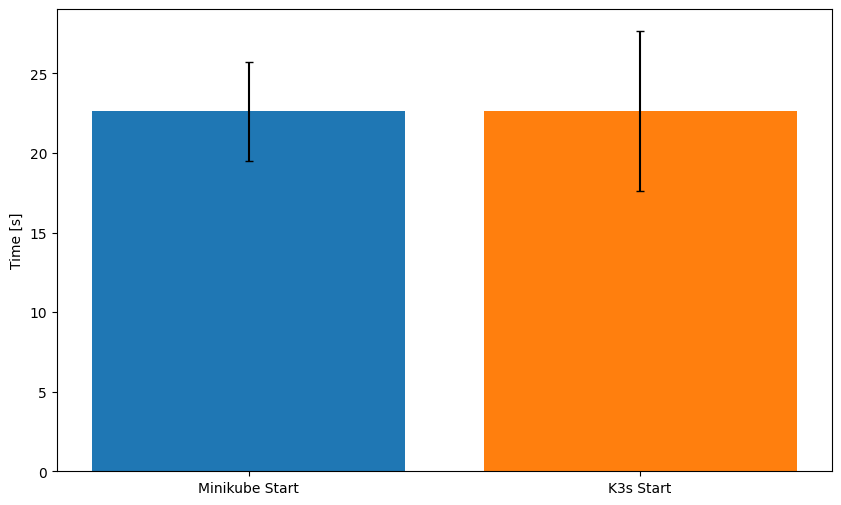

In [ ]:
# zmienić to jak będzie reszta tych danych 
import pandas as pd
import numpy as np
df = pd.read_csv("minikube_time.csv")
df2 = pd.read_csv("k3s_time.csv")

columns = {
    'start_time' : ["Kubernetes  Distribution Start time", "Minikube Start", "K3s Start"],
    'deployment_time' : ["Kubernetes Distribution Deployment time", "Minikube Deployment from YAML and Helmchart", "K3s Deployment from YAML and Helmchart"],
    'stop_time' : ["Kubernetes  Distribution Stop time", "Minikube Stop", "K3s Stop"], 
    'delete_time' : ["Kubernetes  Distribution Delete time", "Minikube Delete", "K3s Delete"]}
for metric, title in columns.items():
    stdev1 = np.std(df[metric])
    stdev2 = np.std(df2[metric])
    plt.figure(figsize=(10, 6))
    x = df[metric].mean()
    plt.bar(title[1], df[metric].mean(), yerr=stdev1, capsize=3)
    plt.bar(title[2], df[metric].mean(), yerr=stdev2, capsize=3)
    # plt.errorbar(x, df[metric], yerr=stdev, capsize=3)
    plt.ylabel("Time [s]")
    plt.title(title[0])
    # plt.xticks(x)
    plt.grid()
    plt.show()

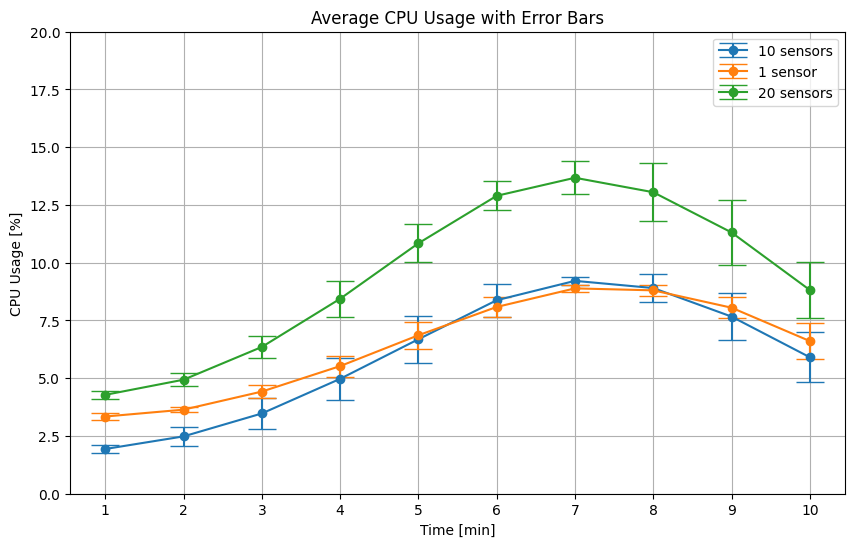

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
cpu_1 = [2.1, 3.2, 4.5, 6.3, 8.2, 9.2, 9.01, 7.8, 6, 4.3, 2.8, 2.2, 1.8]
cpu_2 = [2, 2.73, 3.9, 5.61, 7.5, 9, 9.47, 8.6, 7.2, 5.2, 3.2, 2.3, 1.9]
cpu_3 = [2.3, 3.2, 4.7, 6.3, 8.2, 9.3, 9.2, 8, 6.1, 4.2, 2.8, 2.1]
cpu_4 = [1.92, 2.3, 3.4, 5.01, 5.34, 7, 8.9, 9.45, 9.2, 7.42, 5.71, 3.66, 2.47, 1.8]
cpu_5 = [1.7, 2.06, 2.71, 4.06, 5.9, 7.92,  9.2, 9.34, 8.2, 6.35, 4.6, 3.09, 1.9]
cpu_6 = [1.7, 2.12, 3.11, 4.68, 6.71, 8.51, 9.44, 9.13, 7.74, 6.12, 4.25, 2.9, 2.12]
cpu_7 = [1.9, 2.22, 2.84, 4.07, 5.85, 7.77, 9.09, 9.34, 8.29, 6.84, 4.62, 3.17, 2.03]
cpu_8 = [1.9, 2.18, 2.92, 3.8, 5.74, 8, 9.22, 9.43, 8.5, 7.04, 4.75, 3.24, 2.38, 1.9]
cpu_9 = [1.95, 2.41, 3.41, 5.3, 6.91, 8.56, 9.35, 9.05, 7.75, 5.81, 3,8, 2.6, 1.8]
cpu_10 = [1.89, 2.4, 3.25, 4.6, 6.52, 8.5, 9.27, 8.9, 7.7, 5.8, 4.2, 2.08, 1.8]

cpu_1_1 = [3.39, 3.49, 3.89, 4.89, 6.17, 7.4, 8.7, 9.14, 8.63, 7.42, 6.14, 4.72, 3.8, 3.3]
cpu_2_1 = [3.22, 3.43, 4.75, 6.08, 7.83, 8.7, 9.15, 8.5, 7.46, 5.5, 3.98, 2.8, 2.2, 2.3]
cpu_3_1 = [2.98, 3.68, 4.64, 5.58, 7.2, 8.30, 9.09, 8.92, 8, 6.5, 5.44, 4.4, 3.7, 3.4]
cpu_4_1 = [3.4, 3.65, 4.8, 6.29, 7.45, 8.45, 8.89, 8.55, 7.45, 6.01, 4.77, 3.9, 3.38]
cpu_5_1 = [3.31, 3.57, 4.3, 5.26, 6.64, 8.01, 8.82, 8.85, 8.76, 7.85, 6.70, 5.25, 4.1, 3.4]
cpu_6_1 = [3.3, 3.69, 4.47, 5.6, 7.31, 8.34, 8.95, 8.79, 7.99, 6.5, 5.07, 4,43, 3,74, 3.54]
cpu_7_1 = [3.5, 3.69, 4.12, 5.2, 6.3, 7.85, 8.87, 9, 8.12, 6.97, 5.24, 4.29, 3.44, 3.4]
cpu_8_1 = [3.29, 3.80, 4.68, 5.91, 7.10, 8.32, 8.86, 8.41, 7.53, 5.48, 4.77, 3.48, 3.44]
cpu_9_1 = [3.41, 3.62, 4.3, 5.3, 6.47, 7.96, 8.97, 9.09, 8.30, 6.98, 5.59, 4.7, 4, 3.66]
cpu_10_1 = [3.62, 3.77, 4.27, 5.13, 6.13, 7.52, 8.59, 8.79, 8.29, 6.88, 5.51, 4.58, 3.79]

cpu_1_20 = [4.48, 4.99, 6.29, 8.30, 11.4, 13.7, 14.7, 14.18, 12.25, 9.47, 7, 5.27, 4.4, 4.0]
cpu_2_20 = [4.27, 4.70, 6.19, 8.25, 10.9, 13.41, 14.63, 14.45, 13.17, 10.52, 7.81, 5.5, 4.9]
cpu_3_20 = [4.6, 5.6, 7.08, 9.88, 12.04, 13.08, 14.18, 12.92, 10.52, 8.36, 6.28, 4.94, 4.2]
cpu_4_20 = [4.23, 4.96, 6.45, 8.69, 11.31, 13.51, 14, 13.92, 10.84, 8.6, 6.18, 4.74, 4.04]
cpu_5_20 = [4.08, 4.82, 6.01, 8.51, 10.6, 13.03, 13.8, 13.09, 11.56, 9.04, 6.45, 5.16, 4.6]
cpu_6_20 = [4.09, 4.7, 5.9, 7.48, 9.92, 12.3, 13.16, 13.51, 12.09, 9.27, 6.97, 5.55, 4.4]
cpu_7_20 = [4.37, 5.23, 7.20, 9.57, 11.95, 13.37, 12.65, 10.04, 8.02, 5.88, 4.87, 4.3, 4.3]
cpu_8_20 = [4.24, 4.79, 6.16, 8.13, 10.16, 12.17, 13.6, 13.36, 11.8, 9.45, 7.11, 5.13, 4.5]
cpu_9_20 = [4.3, 4.71, 5.79, 7.5, 9.76, 11.9, 13.03, 12.98, 11.9, 9.3, 7.1, 5.4, 4.6, 4.1]
cpu_10_20 = [4.14, 4.86, 6.46, 8.08, 10.37, 12.49, 13.03, 12.07, 10.96, 8.29, 6.33, 5.19, 4.06]


df1 = pd.DataFrame({
    '1': [cpu_1[0], cpu_2[0], cpu_3[0], cpu_4[0], cpu_5[0], cpu_6[0], cpu_7[0], cpu_8[0], cpu_9[0], cpu_10[0]],
    '2': [cpu_1[1], cpu_2[1], cpu_3[1], cpu_4[1], cpu_5[1], cpu_6[1], cpu_7[1], cpu_8[1], cpu_9[1], cpu_10[1]],
    '3': [cpu_1[2], cpu_2[2], cpu_3[2], cpu_4[2], cpu_5[2], cpu_6[2], cpu_7[2], cpu_8[2], cpu_9[2], cpu_10[2]], 
    '4': [cpu_1[3], cpu_2[3], cpu_3[3], cpu_4[3], cpu_5[3], cpu_6[3], cpu_7[3], cpu_8[3], cpu_9[3], cpu_10[3]],
    '5': [cpu_1[4], cpu_2[4], cpu_3[4], cpu_4[4], cpu_5[4], cpu_6[4], cpu_7[4], cpu_8[4], cpu_9[4], cpu_10[4]],
    '6': [cpu_1[5], cpu_2[5], cpu_3[5], cpu_4[5], cpu_5[5], cpu_6[5], cpu_7[5], cpu_8[5], cpu_9[5], cpu_10[5]],
    '7': [cpu_1[6], cpu_2[6], cpu_3[6], cpu_4[6], cpu_5[6], cpu_6[6], cpu_7[6], cpu_8[6], cpu_9[6], cpu_10[6]],
    '8': [cpu_1[7], cpu_2[7], cpu_3[7], cpu_4[7], cpu_5[7], cpu_6[7], cpu_7[7], cpu_8[7], cpu_9[7], cpu_10[7]],
    '9': [cpu_1[8], cpu_2[8], cpu_3[8], cpu_4[8], cpu_5[8], cpu_6[8], cpu_7[8], cpu_8[8], cpu_9[8], cpu_10[8]],
    '10': [cpu_1[9], cpu_2[9], cpu_3[9], cpu_4[9], cpu_5[9], cpu_6[9], cpu_7[9], cpu_8[9], cpu_9[9], cpu_10[9]]})

df2 = pd.DataFrame({
    '1' : [cpu_1_1[0], cpu_2_1[0], cpu_3_1[0], cpu_4_1[0], cpu_5_1[0], cpu_6_1[0], cpu_7_1[0], cpu_8_1[0], cpu_9_1[0], cpu_10_1[0]],
    '2' : [cpu_1_1[1], cpu_2_1[1], cpu_3_1[1], cpu_4_1[1], cpu_5_1[1], cpu_6_1[1], cpu_7_1[1], cpu_8_1[1], cpu_9_1[1], cpu_10_1[1]],
    '3' : [cpu_1_1[2], cpu_2_1[2], cpu_3_1[2], cpu_4_1[2], cpu_5_1[2], cpu_6_1[2], cpu_7_1[2], cpu_8_1[2], cpu_9_1[2], cpu_10_1[2]],
    '4' : [cpu_1_1[3], cpu_2_1[3], cpu_3_1[3], cpu_4_1[3], cpu_5_1[3], cpu_6_1[3], cpu_7_1[3], cpu_8_1[3], cpu_9_1[3], cpu_10_1[3]], 
    '5' : [cpu_1_1[4], cpu_2_1[4], cpu_3_1[4], cpu_4_1[4], cpu_5_1[4], cpu_6_1[4], cpu_7_1[4], cpu_8_1[4], cpu_9_1[4], cpu_10_1[4]],
    '6' : [cpu_1_1[5], cpu_2_1[5], cpu_3_1[5], cpu_4_1[5], cpu_5_1[5], cpu_6_1[5], cpu_7_1[5], cpu_8_1[5], cpu_9_1[5], cpu_10_1[5]],
    '7' : [cpu_1_1[6], cpu_2_1[6], cpu_3_1[6], cpu_4_1[6], cpu_5_1[6], cpu_6_1[6], cpu_7_1[6], cpu_8_1[6], cpu_9_1[6], cpu_10_1[6]],
    '8' : [cpu_1_1[7], cpu_2_1[7], cpu_3_1[7], cpu_4_1[7], cpu_5_1[7], cpu_6_1[7], cpu_7_1[7], cpu_8_1[7], cpu_9_1[7], cpu_10_1[7]],
    '9' : [cpu_1_1[8], cpu_2_1[8], cpu_3_1[8], cpu_4_1[8], cpu_5_1[8], cpu_6_1[8], cpu_7_1[8], cpu_8_1[8], cpu_9_1[8], cpu_10_1[8]],
    '10': [cpu_1_1[9], cpu_2_1[9], cpu_3_1[9], cpu_4_1[9], cpu_5_1[9], cpu_6_1[9], cpu_7_1[9], cpu_8_1[9], cpu_9_1[9], cpu_10_1[9]]})

df3 = pd.DataFrame({
    '1' : [cpu_1_20[0], cpu_2_20[0], cpu_3_20[0], cpu_4_20[0], cpu_5_20[0], cpu_6_20[0], cpu_7_20[0], cpu_8_20[0], cpu_9_20[0], cpu_10_20[0]],
    '2' : [cpu_1_20[1], cpu_2_20[1], cpu_3_20[1], cpu_4_20[1], cpu_5_20[1], cpu_6_20[1], cpu_7_20[1], cpu_8_20[1], cpu_9_20[1], cpu_10_20[1]],
    '3' : [cpu_1_20[2], cpu_2_20[2], cpu_3_20[2], cpu_4_20[2], cpu_5_20[2], cpu_6_20[2], cpu_7_20[2], cpu_8_20[2], cpu_9_20[2], cpu_10_20[2]],
    '4' : [cpu_1_20[3], cpu_2_20[3], cpu_3_20[3], cpu_4_20[3], cpu_5_20[3], cpu_6_20[3], cpu_7_20[3], cpu_8_20[3], cpu_9_20[3], cpu_10_20[3]],
    '5' : [cpu_1_20[4], cpu_2_20[4], cpu_3_20[4], cpu_4_20[4], cpu_5_20[4], cpu_6_20[4], cpu_7_20[4], cpu_8_20[4], cpu_9_20[4], cpu_10_20[4]],
    '6' : [cpu_1_20[5], cpu_2_20[5], cpu_3_20[5], cpu_4_20[5], cpu_5_20[5], cpu_6_20[5], cpu_7_20[5], cpu_8_20[5], cpu_9_20[5], cpu_10_20[5]],
    '7' : [cpu_1_20[6], cpu_2_20[6], cpu_3_20[6], cpu_4_20[6], cpu_5_20[6], cpu_6_20[6], cpu_7_20[6], cpu_8_20[6], cpu_9_20[6], cpu_10_20[6]],
    '8' : [cpu_1_20[7], cpu_2_20[7], cpu_3_20[7], cpu_4_20[7], cpu_5_20[7], cpu_6_20[7], cpu_7_20[7], cpu_8_20[7], cpu_9_20[7], cpu_10_20[7]],
    '9' : [cpu_1_20[8], cpu_2_20[8], cpu_3_20[8], cpu_4_20[8], cpu_5_20[8], cpu_6_20[8], cpu_7_20[8], cpu_8_20[8], cpu_9_20[8], cpu_10_20[8]],
    '10': [cpu_1_20[9], cpu_2_20[9], cpu_3_20[9], cpu_4_20[9], cpu_5_20[9], cpu_6_20[9], cpu_7_20[9], cpu_8_20[9], cpu_9_20[9], cpu_10_20[9]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []
for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std()) 

for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())
for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1 sensor', '10 sensors', '20 sensors'])
plt.title("Average CPU Usage with Error Bars")
plt.ylim(0, 20)
plt.xlabel("Time [min]")
plt.ylabel("CPU Usage [%]")
plt.grid()
plt.show()

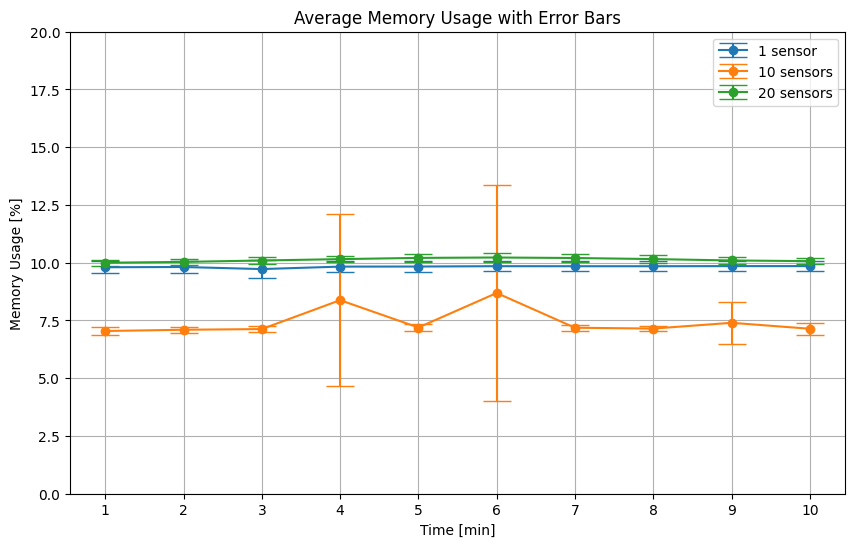

In [11]:
mem_1 = [6.7, 6.8, 6.9, 7.05, 7.03, 7, 7, 7, 7, 6.9]
mem_2 = [6.9, 7.01, 7.04, 7.08, 7.09, 7.07, 7.03, 7, 6.9, 6.8]
mem_3 = [7, 7.09, 7.13, 7.14, 7.13, 7.09, 7.05, 7.03, 7.03, 7.03]
mem_4 = [7.02, 7.03, 7.07, 7.12, 7.13, 7.16, 7.15, 7.12, 7.06, 7.06]
mem_5 = [7.07, 7.13, 7.20, 7.24, 7.28, 7.25, 7.2, 7.14, 10, 7.8, 7.08]
mem_6 = [7.06, 7.11, 7.17, 7.25, 7.25, 7.23, 7.16, 7.10, 7.07, 7.07]
mem_7 = [7.12, 7.16, 7.19, 7.23, 7.26, 7.28, 7.26, 7.25, 7.19, 7.17]
mem_8 = [7.25, 7.28, 7.32, 7.36, 7.41, 7.43, 7.41, 7.3, 7.28, 7.2, 7.19]
mem_9 = [7.16, 7.20, 7.26, 7.32, 7.37, 7.38, 7.36, 7.30, 7.23, 7.19, 7.17]
mem_10 = [7.16, 7.17, 7,19, 7,22, 7.24, 7.25, 7.23, 7.20, 7.16, 7.13, 7.13]

mem_1_1 = [9.18, 9.20, 9.26, 9.31, 9.30, 9.40, 9.38, 9.37, 9.37, 9.36]
mem_2_1 = [9.57, 9.57, 9.56, 9.55, 9.55, 9.55, 9.55, 9.54, 9.54, 9.54]
mem_3_1 = [9.78, 9.84, 9.88, 9.92, 9.97, 10, 9.97, 9.95, 9.93, 9.92]
mem_4_1 = [9.97, 9.99, 10, 10, 10, 10, 9.98, 9.95, 9.93, 9.93, 9.91]
mem_5_1 = [9.97, 9.99, 10, 10, 9.99, 9.98, 9.97, 9.96, 9.96, 9.97, 9.97]
mem_6_1 = [9.96, 9.95, 9.94, 9.92, 9.92, 9.95, 10, 10.07, 10.14, 10.14]
mem_7_1 = [9.92, 9.91, 9.90, 9.89, 9.88, 9.87, 9.88, 9.90, 9.92, 9.93]
mem_8_1 = [9.88, 9.87, 9.86, 9.87, 9.88, 9.89, 9.90, 9.90, 9.92, 9.94]
mem_9_1 = [9.98, 9.99, 10, 9.99, 9.98, 9.97, 9.95, 9.93, 9.91, 9.89]
mem_10_1 = [9.83, 9.84, 8.85, 9.87, 9.88, 9.89, 9.90, 9.91, 9.91, 9.91]

mem_1_20 = [9.77, 9.77, 9.82, 9.89, 9.90, 9.95, 9.97, 9.98, 9.94, 9.90]
mem_2_20 = [9.87, 9.91, 9.96, 10.04, 10.14, 10.16, 10.14, 10.08, 10.04, 10]
mem_3_20 = [9.91, 9.94, 9.99, 10.04, 10.08, 10.07, 10.05, 10.03, 9.98, 9.97]
mem_4_20 = [9.99, 10.05, 10.12, 10.16, 10.20, 10.18, 10.10, 10.06, 10, 9.98]
mem_5_20 = [9.94, 9.99, 10.04, 10.14, 10.19, 10.18, 10.13, 10.07, 10, 9.99]
mem_6_20 = [10.12, 10.18, 10.28, 10.32, 10.32, 10.32, 10.28, 10.22, 10.15, 10.10]
mem_7_20 = [10.07, 10.08, 10.12, 10.17, 10.20, 10.24, 10.23, 10.18, 10.12, 10.11]
mem_8_20 = [10.11, 10.13, 10.20, 10.25, 10.28, 10.29, 10.28, 10.24, 10.17, 10.14]
mem_9_20 = [10.09, 10.13, 10.16, 10.21, 10.26, 10.25, 10.22, 10.16, 10.12, 10.09]
mem_10_20 = [10.12, 10.18, 10.27, 10.34, 10.52, 10.62, 10.64, 10.56, 10.46, 10.4]


df1= pd.DataFrame({
    '1' : [mem_1[0], mem_2[0], mem_3[0], mem_4[0], mem_5[0], mem_6[0], mem_7[0], mem_8[0], mem_9[0], mem_10[0]],
    '2' : [mem_1[1], mem_2[1], mem_3[1], mem_4[1], mem_5[1], mem_6[1], mem_7[1], mem_8[1], mem_9[1], mem_10[1]],
    '3' : [mem_1[2], mem_2[2], mem_3[2], mem_4[2], mem_5[2], mem_6[2], mem_7[2], mem_8[2], mem_9[2], mem_10[2]],
    '4' : [mem_1[3], mem_2[3], mem_3[3], mem_4[3], mem_5[3], mem_6[3], mem_7[3], mem_8[3], mem_9[3], mem_10[3]],
    '5' : [mem_1[4], mem_2[4], mem_3[4], mem_4[4], mem_5[4], mem_6[4], mem_7[4], mem_8[4], mem_9[4], mem_10[4]],
    '6' : [mem_1[5], mem_2[5], mem_3[5], mem_4[5], mem_5[5], mem_6[5], mem_7[5], mem_8[5], mem_9[5], mem_10[5]],
    '7' : [mem_1[6], mem_2[6], mem_3[6], mem_4[6], mem_5[6], mem_6[6], mem_7[6], mem_8[6], mem_9[6], mem_10[6]],
    '8' : [mem_1[7], mem_2[7], mem_3[7], mem_4[7], mem_5[7], mem_6[7], mem_7[7], mem_8[7], mem_9[7], mem_10[7]],
    '9' : [mem_1[8], mem_2[8], mem_3[8], mem_4[8], mem_5[8], mem_6[8], mem_7[8], mem_8[8], mem_9[8], mem_10[8]],
    '10': [mem_1[9], mem_2[9], mem_3[9], mem_4[9], mem_5[9], mem_6[9], mem_7[9], mem_8[9], mem_9[9], mem_10[9]]})

df2 = pd.DataFrame({
    '1' : [mem_1_1[0], mem_2_1[0], mem_3_1[0], mem_4_1[0], mem_5_1[0], mem_6_1[0], mem_7_1[0], mem_8_1[0], mem_9_1[0], mem_10_1[0]],
    '2' : [mem_1_1[1], mem_2_1[1], mem_3_1[1], mem_4_1[1], mem_5_1[1], mem_6_1[1], mem_7_1[1], mem_8_1[1], mem_9_1[1], mem_10_1[1]],
    '3' : [mem_1_1[2], mem_2_1[2], mem_3_1[2], mem_4_1[2], mem_5_1[2], mem_6_1[2], mem_7_1[2], mem_8_1[2], mem_9_1[2], mem_10_1[2]],
    '4' : [mem_1_1[3], mem_2_1[3], mem_3_1[3], mem_4_1[3], mem_5_1[3], mem_6_1[3], mem_7_1[3], mem_8_1[3], mem_9_1[3], mem_10_1[3]],
    '5' : [mem_1_1[4], mem_2_1[4], mem_3_1[4], mem_4_1[4], mem_5_1[4], mem_6_1[4], mem_7_1[4], mem_8_1[4], mem_9_1[4], mem_10_1[4]],
    '6' : [mem_1_1[5], mem_2_1[5], mem_3_1[5], mem_4_1[5], mem_5_1[5], mem_6_1[5], mem_7_1[5], mem_8_1[5], mem_9_1[5], mem_10_1[5]],
    '7' : [mem_1_1[6], mem_2_1[6], mem_3_1[6], mem_4_1[6], mem_5_1[6], mem_6_1[6], mem_7_1[6], mem_8_1[6], mem_9_1[6], mem_10_1[6]],
    '8' : [mem_1_1[7], mem_2_1[7], mem_3_1[7], mem_4_1[7], mem_5_1[7], mem_6_1[7], mem_7_1[7], mem_8_1[7], mem_9_1[7], mem_10_1[7]],
    '9' : [mem_1_1[8], mem_2_1[8], mem_3_1[8], mem_4_1[8], mem_5_1[8], mem_6_1[8], mem_7_1[8], mem_8_1[8], mem_9_1[8], mem_10_1[8]],
    '10': [mem_1_1[9], mem_2_1[9], mem_3_1[9], mem_4_1[9], mem_5_1[9], mem_6_1[9], mem_7_1[9], mem_8_1[9], mem_9_1[9], mem_10_1[9]]})

df3 = pd.DataFrame({
    '1' : [mem_1_20[0], mem_2_20[0], mem_3_20[0], mem_4_20[0], mem_5_20[0], mem_6_20[0], mem_7_20[0], mem_8_20[0], mem_9_20[0], mem_10_20[0]],
    '2' : [mem_1_20[1], mem_2_20[1], mem_3_20[1], mem_4_20[1], mem_5_20[1], mem_6_20[1], mem_7_20[1], mem_8_20[1], mem_9_20[1], mem_10_20[1]],
    '3' : [mem_1_20[2], mem_2_20[2], mem_3_20[2], mem_4_20[2], mem_5_20[2], mem_6_20[2], mem_7_20[2], mem_8_20[2], mem_9_20[2], mem_10_20[2]],
    '4' : [mem_1_20[3], mem_2_20[3], mem_3_20[3], mem_4_20[3], mem_5_20[3], mem_6_20[3], mem_7_20[3], mem_8_20[3], mem_9_20[3], mem_10_20[3]],
    '5' : [mem_1_20[4], mem_2_20[4], mem_3_20[4], mem_4_20[4], mem_5_20[4], mem_6_20[4], mem_7_20[4], mem_8_20[4], mem_9_20[4], mem_10_20[4]],
    '6' : [mem_1_20[5], mem_2_20[5], mem_3_20[5], mem_4_20[5], mem_5_20[5], mem_6_20[5], mem_7_20[5], mem_8_20[5], mem_9_20[5], mem_10_20[5]],
    '7' : [mem_1_20[6], mem_2_20[6], mem_3_20[6], mem_4_20[6], mem_5_20[6], mem_6_20[6], mem_7_20[6], mem_8_20[6], mem_9_20[6], mem_10_20[6]],
    '8' : [mem_1_20[7], mem_2_20[7], mem_3_20[7], mem_4_20[7], mem_5_20[7], mem_6_20[7], mem_7_20[7], mem_8_20[7], mem_9_20[7], mem_10_20[7]],
    '9' : [mem_1_20[8], mem_2_20[8], mem_3_20[8], mem_4_20[8], mem_5_20[8], mem_6_20[8], mem_7_20[8], mem_8_20[8], mem_9_20[8], mem_10_20[8]],
    '10': [mem_1_20[9], mem_2_20[9], mem_3_20[9], mem_4_20[9], mem_5_20[9], mem_6_20[9], mem_7_20[9], mem_8_20[9], mem_9_20[9], mem_10_20[9]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []

for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())


for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std())


for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1 sensor', '10 sensors', '20 sensors'])
plt.title("Average Memory Usage with Error Bars")
plt.ylim(0, 20)
plt.xlabel("Time [min]")
plt.ylabel("Memory Usage [%]")
plt.grid()
plt.show()